In [1]:
# CRE IFRS9 Baseline, 2006-Q1 to 2017-Q4
import json
import sys
from pathlib import Path

SNAPSHOT_ID = "item_d982dc3d4a34"
TABLE_NAME = "Data"

# Find the workspace from the kernel's current directory, avoiding
# machine-specific absolute paths.
workspace_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "source-codes" / "backend").is_dir()),
    None,
)
if workspace_root is None:
    raise FileNotFoundError(
        "Could not locate the DataWorkbench workspace from the current directory."
    )

backend_dir = workspace_root / "source-codes" / "backend"
experiment_dir = (
    workspace_root / "experiments" / "test-lab" / "t2_d11_dir_consistency"
)
for import_dir in (backend_dir, experiment_dir):
    import_path = str(import_dir)
    if import_path not in sys.path:
        sys.path.insert(0, import_path)

from functions import extract_saved_schema

repository = extract_saved_schema._load_repository()
schema = extract_saved_schema.extract_saved_schema(
    repository,
    snapshot_id=SNAPSHOT_ID,
    table=TABLE_NAME,
)

# Supported roles: feature, target, score, identifier, period, date,
# weight, group, and ignore.
agent_input = extract_saved_schema.build_agent_input(
    schema,
    roles={"feature", "target", "score", "group"},
    include_statistics=False,
)
agent_json = json.dumps(agent_input, indent=2)
print(agent_json)


[
  {
    "name": "CLTV",
    "type": "float64",
    "role": "Feature",
    "description": "Current Loan-to-Value (%), target 50-70; rises ahead of default Simulation: 4.50% newly missing under paired origination-rating tails."
  },
  {
    "name": "DSCR",
    "type": "float64",
    "role": "Feature",
    "description": "Debt Service Coverage Ratio = NOI / (interest_rate x debt), interest-only basis; falls ahead of default Simulation: 4.50% newly missing under paired origination-rating tails."
  },
  {
    "name": "NOI",
    "type": "float64",
    "role": "Feature",
    "description": "Net Operating Income (USD); = debt x debt_yield Simulation: 3.20% newly missing under uniform random rows."
  },
  {
    "name": "debt",
    "type": "float64",
    "role": "Feature",
    "description": "Outstanding loan balance at year-end (USD); equals the year-end outstanding_balance; always < loan_limit"
  },
  {
    "name": "debt_yield",
    "type": "float64",
    "role": "Feature",
    "description"

In [2]:
from analysis_runtime.snapshots import SnapshotLoader

df = SnapshotLoader().load_table(
    snapshot_id=SNAPSHOT_ID,
    table=TABLE_NAME,
)

print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns.")
display(df.head())


Loaded 30,252 rows and 43 columns.


,facility_id,obligor_id,year,rating,pd_midpoint_pct,property_type,reporting_quarter,months_on_book,accrual_indicator,non_accrual_indicator,...,interest_rate,interest_type,spread,loan_payment_type,loan_type,origination_rating,state,segment,net_interest_margin,nim_group
0,FAC00000_1,OBL00000,2006,4.5,2.87,Industrial,2006-Q1,2,1,0,...,5.96,Floating,1.99,Interest only,Revolving,6.5,Arizona,non_multifamily,2.3610,Medium
1,FAC00000_1,OBL00000,2006,4.5,2.87,Industrial,2006-Q2,5,1,0,...,5.96,Floating,1.99,Interest only,Revolving,6.5,Arizona,non_multifamily,2.2459,Low
2,FAC00000_1,OBL00000,2006,4.5,2.87,Industrial,2006-Q3,8,1,0,...,5.96,Floating,1.99,Interest only,Revolving,6.5,Arizona,non_multifamily,2.5330,Medium
3,FAC00000_1,OBL00000,2006,4.5,2.87,Industrial,2006-Q4,11,1,0,...,5.96,Floating,1.99,Interest only,Revolving,6.5,Arizona,non_multifamily,2.4882,Medium
4,FAC00000_1,OBL00000,2007,1.5,58.00,Industrial,2007-Q1,14,1,0,...,5.96,Floating,1.99,Interest only,Revolving,6.5,Arizona,non_multifamily,2.8758,High


In [7]:
# RUN 0: Bootstrap everything this cell needs so it can run after a fresh kernel start.
import importlib
import sys
import time
from pathlib import Path

# Identify the snapshot and its registered table.
# SNAPSHOT_ID = "item_d982dc3d4a34"
# TABLE_NAME = "Data"
SNAPSHOT_ID = "item_e243fa4e72f4"
TABLE_NAME = "mr_pd_sample"

# Locate the workspace by walking upward from the notebook's current directory.
workspace_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "source-codes" / "backend").is_dir()),
    None,
)
if workspace_root is None:
    raise FileNotFoundError(
        "Could not locate the DataWorkbench workspace from the current directory."
    )

# Add the backend and this experiment to Python's import search path.
backend_dir = workspace_root / "source-codes" / "backend"
experiment_dir = (
    workspace_root / "experiments" / "test-lab" / "t2_d11_dir_consistency"
)
for import_dir in (backend_dir, experiment_dir):
    import_path = str(import_dir)
    if import_path not in sys.path:
        sys.path.insert(0, import_path)

# Load the saved schema containing each column's name, description, type, and role.
from functions import extract_saved_schema
repository = extract_saved_schema._load_repository()
schema = extract_saved_schema.extract_saved_schema(
    repository,
    snapshot_id=SNAPSHOT_ID,
    table=TABLE_NAME,
)

# RUN 1: Configure the eligible schema roles; every matching column is checked.
ELIGIBLE_ROLES = {"feature", "score", "group"}

# RUN 2: Import the deterministic matcher, the LLM adjudicator, and the batch runner.
import pandas as pd
from functions.feature_matching import load_kb, load_terminology
from functions.llm_semantic_adjudication import (
    CONTRACT_VERSION_V0_2,
    PROMPT_VERSION_V0_2,
    OpenAISemanticAdjudicator,
    configured_model,
    create_openai_client,
    load_adjudication_prompt,
)
from functions import llm_semantic_adjudication_validation
llm_semantic_adjudication_validation = importlib.reload(
    llm_semantic_adjudication_validation
)

# RUN 3: Build column metadata from the saved schema produced in the first cell.
schema_columns = pd.DataFrame(
    {
        "name": column["name"],
        "description": column.get("description") or "",
        "type": column.get("data_type"),
        "role": column.get("role"),
    }
    for table in schema["tables"]
    for column in table["columns"]
)

# RUN 4: Select every column whose saved role is Feature, Score, or Group.
eligible_columns = schema_columns[
    schema_columns["role"].fillna("").str.casefold().isin(ELIGIBLE_ROLES)
].copy()

# RUN 5: Preserve the original saved-schema order for the complete eligible set.
selected_metadata = eligible_columns.reset_index(drop=True)

# RUN 6: Pass only column name and description into matching/adjudication.
# Role and type are deliberately excluded from the LLM input and reattached later.
prediction_input = selected_metadata.rename(
    columns={"name": "feature_name"}
).loc[:, ["feature_name", "description"]]

# RUN 7: Load the versioned KB, terminology, and fixed v0.2 adjudication prompt.
kb = load_kb(experiment_dir / "kb" / "pd_directionality_kb_v0_3.yaml")
terminology = load_terminology(
    experiment_dir / "kb" / "credit_risk_abbreviations_v0_2.yaml"
)
prompt = load_adjudication_prompt(
    experiment_dir / "prompts" / "semantic_feature_adjudication_v0_2.txt"
)

# RUN 8: Create the configured OpenAI client from the experiment .env file.
# Exact deterministic KB matches bypass the API even though the client is configured.
model = configured_model(experiment_dir / ".env")
client = create_openai_client(experiment_dir / ".env")
adjudicator = OpenAISemanticAdjudicator(
    client=client,
    prompt=prompt,
    model=model,
    prompt_version=PROMPT_VERSION_V0_2,
    contract_version=CONTRACT_VERSION_V0_2,
)

# RUN 9: Configure bounded concurrency and persistent local checkpointing.
MAX_CONCURRENCY = 4
checkpoint_path = (
    experiment_dir / ".runtime"
    / f"directionality_adjudication_{SNAPSHOT_ID}_kb_v0_3.jsonl"
)

# Print completed work while the batch runs.
def show_directionality_progress(index, total, feature_name, adjudication_used):
    route = "semantic adjudication" if adjudication_used else "deterministic KB match"
    print(f"[{index}/{total}] {feature_name}: {route}")

# RUN 10: Match each column to the KB; invoke the LLM only for non-exact cases.
print(
    f"Starting {len(prediction_input)} columns with up to "
    f"{MAX_CONCURRENCY} concurrent requests. Checkpoint: {checkpoint_path}"
)
batch_started = time.perf_counter()
predictions = llm_semantic_adjudication_validation.run_adjudication_predictions(
    prediction_input,
    kb,
    terminology,
    adjudicator,
    progress=show_directionality_progress,
    max_concurrency=MAX_CONCURRENCY,
    checkpoint_path=checkpoint_path,
)
batch_seconds = time.perf_counter() - batch_started
live_calls = predictions[
    predictions['adjudication_used'] & ~predictions['checkpoint_hit']
]
print(
    f"Completed in {batch_seconds:.2f}s: {len(live_calls)} live calls, "
    f"{int(predictions['checkpoint_hit'].sum())} checkpoint hits."
)
if not live_calls.empty:
    print(
        f"Live API latency: median={live_calls['api_call_seconds'].median():.2f}s, "
        f"max={live_calls['api_call_seconds'].max():.2f}s."
    )

# RUN 11: Reattach role/type after inference and tag deterministic versus LLM routing.
column_context = selected_metadata.rename(
    columns={"name": "feature_name"}
).loc[:, ["feature_name", "type", "role"]]
results = predictions.merge(
    column_context, on="feature_name", how="left", validate="one_to_one"
)
results["resolution_method"] = results["adjudication_used"].map(
    {False: "deterministic", True: "llm"}
)

# RUN 12: Attach KB directionality details only after matching/LLM inference is complete.
kb_rules = {rule["feature"]: rule for rule in kb["feature_rules"]}
for output_column, kb_field in {
    "kb_feature_family": "feature_family",
    "kb_definition": "definition",
    "kb_risk_outcome": "risk_outcome",
    "kb_expected_direction": "expected_direction",
    "kb_knowledge_strength": "knowledge_strength",
    "kb_rationale": "rationale",
}.items():
    results[output_column] = results["final_canonical_feature"].map(
        lambda feature: kb_rules.get(feature, {}).get(kb_field)
    )

# RUN 13: Convert canonical KB direction to the selected column's orientation.
# An inverse representation reverses increasing/decreasing; other directions stay unchanged.
inverse_direction = {"increasing": "decreasing", "decreasing": "increasing"}
def direction_for_selected_column(row):
    if row["final_decision"] == "NOT_DIRECTIONAL":
        return "not_applicable"
    if row["final_decision"] == "INSUFFICIENT_CONTEXT":
        return "insufficient_context"
    if row["final_decision"] == "NO_CANDIDATE_MATCH":
        return "no_candidate_match"
    if row["final_decision"] != "MATCH":
        return None
    if row["final_representation_orientation"] == "UNDETERMINED":
        return "undetermined"
    if row["final_representation_orientation"] == "INVERSE":
        return inverse_direction.get(
            row["kb_expected_direction"], row["kb_expected_direction"]
        )
    return row["kb_expected_direction"]

results["column_expected_direction"] = results.apply(
    direction_for_selected_column, axis=1
)

# RUN 14: Select detailed audit columns for review and CSV export.
result_columns = [
    "feature_name", "description", "type", "role", "knowledge_base_version",
    "resolution_method", "checkpoint_hit", "api_call_seconds",
    "python_match_status", "python_match_method",
    "python_candidate_1", "python_candidate_1_score",
    "python_candidate_2", "python_candidate_2_score",
    "python_candidate_3", "python_candidate_3_score",
    "final_decision", "final_canonical_feature",
    "final_representation_orientation", "column_expected_direction",
    "kb_expected_direction", "kb_knowledge_strength",
    "kb_feature_family", "kb_definition", "kb_risk_outcome",
    "kb_rationale", "llm_decision", "llm_selected_candidate",
    "llm_representation_orientation", "llm_reason",
    "model_identifier", "prompt_version",
    "adjudication_contract_version", "response_id",
    "api_call_succeeded", "contract_valid",
    "contract_validation_result", "validation_error",
    "user_review_required", "structured_adjudication_result",
]
directionality_results = results.loc[:, result_columns].copy()

# RUN 15: Write one auditable row per eligible column to CSV.
output_dir = experiment_dir / "output"
output_dir.mkdir(parents=True, exist_ok=True)
csv_path = output_dir / f"directionality_results_{SNAPSHOT_ID}_kb_v0_3.csv"
directionality_results.to_csv(csv_path, index=False)

# RUN 16: Show the final results and the exact CSV location.
display(directionality_results)
print(f"Wrote {len(directionality_results)} rows to {csv_path}")


Starting 21 columns with up to 4 concurrent requests. Checkpoint: c:\Src\DataWorkbench\experiments\test-lab\t2_d11_dir_consistency\.runtime\directionality_adjudication_item_e243fa4e72f4_kb_v0_3.jsonl
[1/21] current_balance: deterministic KB match
[2/21] months_on_book: deterministic KB match
[3/21] original_ltv: deterministic KB match
[4/21] unemployment: deterministic KB match
[5/21] dpd_current: semantic adjudication
[6/21] arrears_months_12m: semantic adjudication
[7/21] dod_regime_version: semantic adjudication
[8/21] base_rate: semantic adjudication
[9/21] ever_forborne: semantic adjudication
[10/21] employment_type: semantic adjudication
[11/21] forbearance_flag: semantic adjudication
[12/21] ftb_flag: semantic adjudication
[13/21] hpi_yoy: semantic adjudication
[14/21] income_at_origination: semantic adjudication
[15/21] indexed_ltv_asof: semantic adjudication
[16/21] max_dpd_12m: semantic adjudication
[17/21] rate_type: semantic adjudication
[18/21] product: semantic adjudicati

,feature_name,description,type,role,knowledge_base_version,resolution_method,checkpoint_hit,api_call_seconds,python_match_status,python_match_method,...,model_identifier,prompt_version,adjudication_contract_version,response_id,api_call_succeeded,contract_valid,contract_validation_result,validation_error,user_review_required,structured_adjudication_result
0,arrears_months_12m,,int64,Feature,0.3,llm,False,2.640726,candidate_match,rapidfuzz_tfidf,...,gpt-5.4-mini,semantic_feature_adjudication_v0_2,semantic_feature_adjudication_contract_v0_2,resp_061e2dfecd26268d016a966d0e380c819498a946c...,True,True,valid,None,True,"{""decision"": ""MATCH"", ""selected_candidate"": ""d..."
1,base_rate,,float64,Feature,0.3,llm,False,3.823948,candidate_match,rapidfuzz_tfidf,...,gpt-5.4-mini,semantic_feature_adjudication_v0_2,semantic_feature_adjudication_contract_v0_2,resp_0e7b5d0a5d282558016a966d0e54788193a235f20...,True,True,valid,None,True,"{""decision"": ""INSUFFICIENT_CONTEXT"", ""selected..."
2,current_balance,,float64,Feature,0.3,deterministic,False,NaN,exact_match,deterministic_exact,...,NaN,NaN,NaN,NaN,False,True,not_applicable,None,False,NaN
3,dod_regime_version,,str,Feature,0.3,llm,False,2.746241,no_match,no_lexical_evidence,...,gpt-5.4-mini,semantic_feature_adjudication_v0_2,semantic_feature_adjudication_contract_v0_2,resp_0e9d182e70c7a906016a966d0e470881979cdda92...,True,True,valid,None,True,"{""decision"": ""NOT_DIRECTIONAL"", ""selected_cand..."
4,dpd_current,,int64,Feature,0.3,llm,False,2.568985,candidate_match,rapidfuzz_tfidf,...,gpt-5.4-mini,semantic_feature_adjudication_v0_2,semantic_feature_adjudication_contract_v0_2,resp_0b041bdcb6eb99cf016a966d0e60fc81969e388ec...,True,True,valid,None,True,"{""decision"": ""MATCH"", ""selected_candidate"": ""d..."
5,employment_type,,str,Feature,0.3,llm,False,1.676686,no_match,no_lexical_evidence,...,gpt-5.4-mini,semantic_feature_adjudication_v0_2,semantic_feature_adjudication_contract_v0_2,resp_0db62ba3297521d4016a966d1015008193ba9b660...,True,True,valid,None,True,"{""decision"": ""NOT_DIRECTIONAL"", ""selected_cand..."
6,ever_forborne,,int64,Feature,0.3,llm,False,1.401503,no_match,no_lexical_evidence,...,gpt-5.4-mini,semantic_feature_adjudication_v0_2,semantic_feature_adjudication_contract_v0_2,resp_042d4e7dba24826d016a966d100df481979071eb8...,True,True,valid,None,True,"{""decision"": ""NOT_DIRECTIONAL"", ""selected_cand..."
7,forbearance_flag,,int64,Feature,0.3,llm,False,2.103522,no_match,no_lexical_evidence,...,gpt-5.4-mini,semantic_feature_adjudication_v0_2,semantic_feature_adjudication_contract_v0_2,resp_0cafaae24e1fb46e016a966d1035f4819790660ae...,True,True,valid,None,True,"{""decision"": ""NOT_DIRECTIONAL"", ""selected_cand..."
8,ftb_flag,,int64,Feature,0.3,llm,False,1.582063,no_match,no_lexical_evidence,...,gpt-5.4-mini,semantic_feature_adjudication_v0_2,semantic_feature_adjudication_contract_v0_2,resp_09ab2ab645abee38016a966d113144819791d1f09...,True,True,valid,None,True,"{""decision"": ""INSUFFICIENT_CONTEXT"", ""selected..."
9,hpi_yoy,,float64,Feature,0.3,llm,False,1.545781,candidate_match,rapidfuzz_tfidf,...,gpt-5.4-mini,semantic_feature_adjudication_v0_2,semantic_feature_adjudication_contract_v0_2,resp_0e92df44c57e595e016a966d1168a881939438d7c...,True,True,valid,None,True,"{""decision"": ""MATCH"", ""selected_candidate"": ""h..."


Wrote 21 rows to c:\Src\DataWorkbench\experiments\test-lab\t2_d11_dir_consistency\output\directionality_results_item_e243fa4e72f4_kb_v0_3.csv


## Empirical evidence overlaid with expected direction

The solid line shows the observed reference mean in each feature quantile bin. The dashed line is a symbolic expected sign, not a fitted magnitude. Non-monotonic expectations are labeled without assuming a U-shape or inverted U-shape.

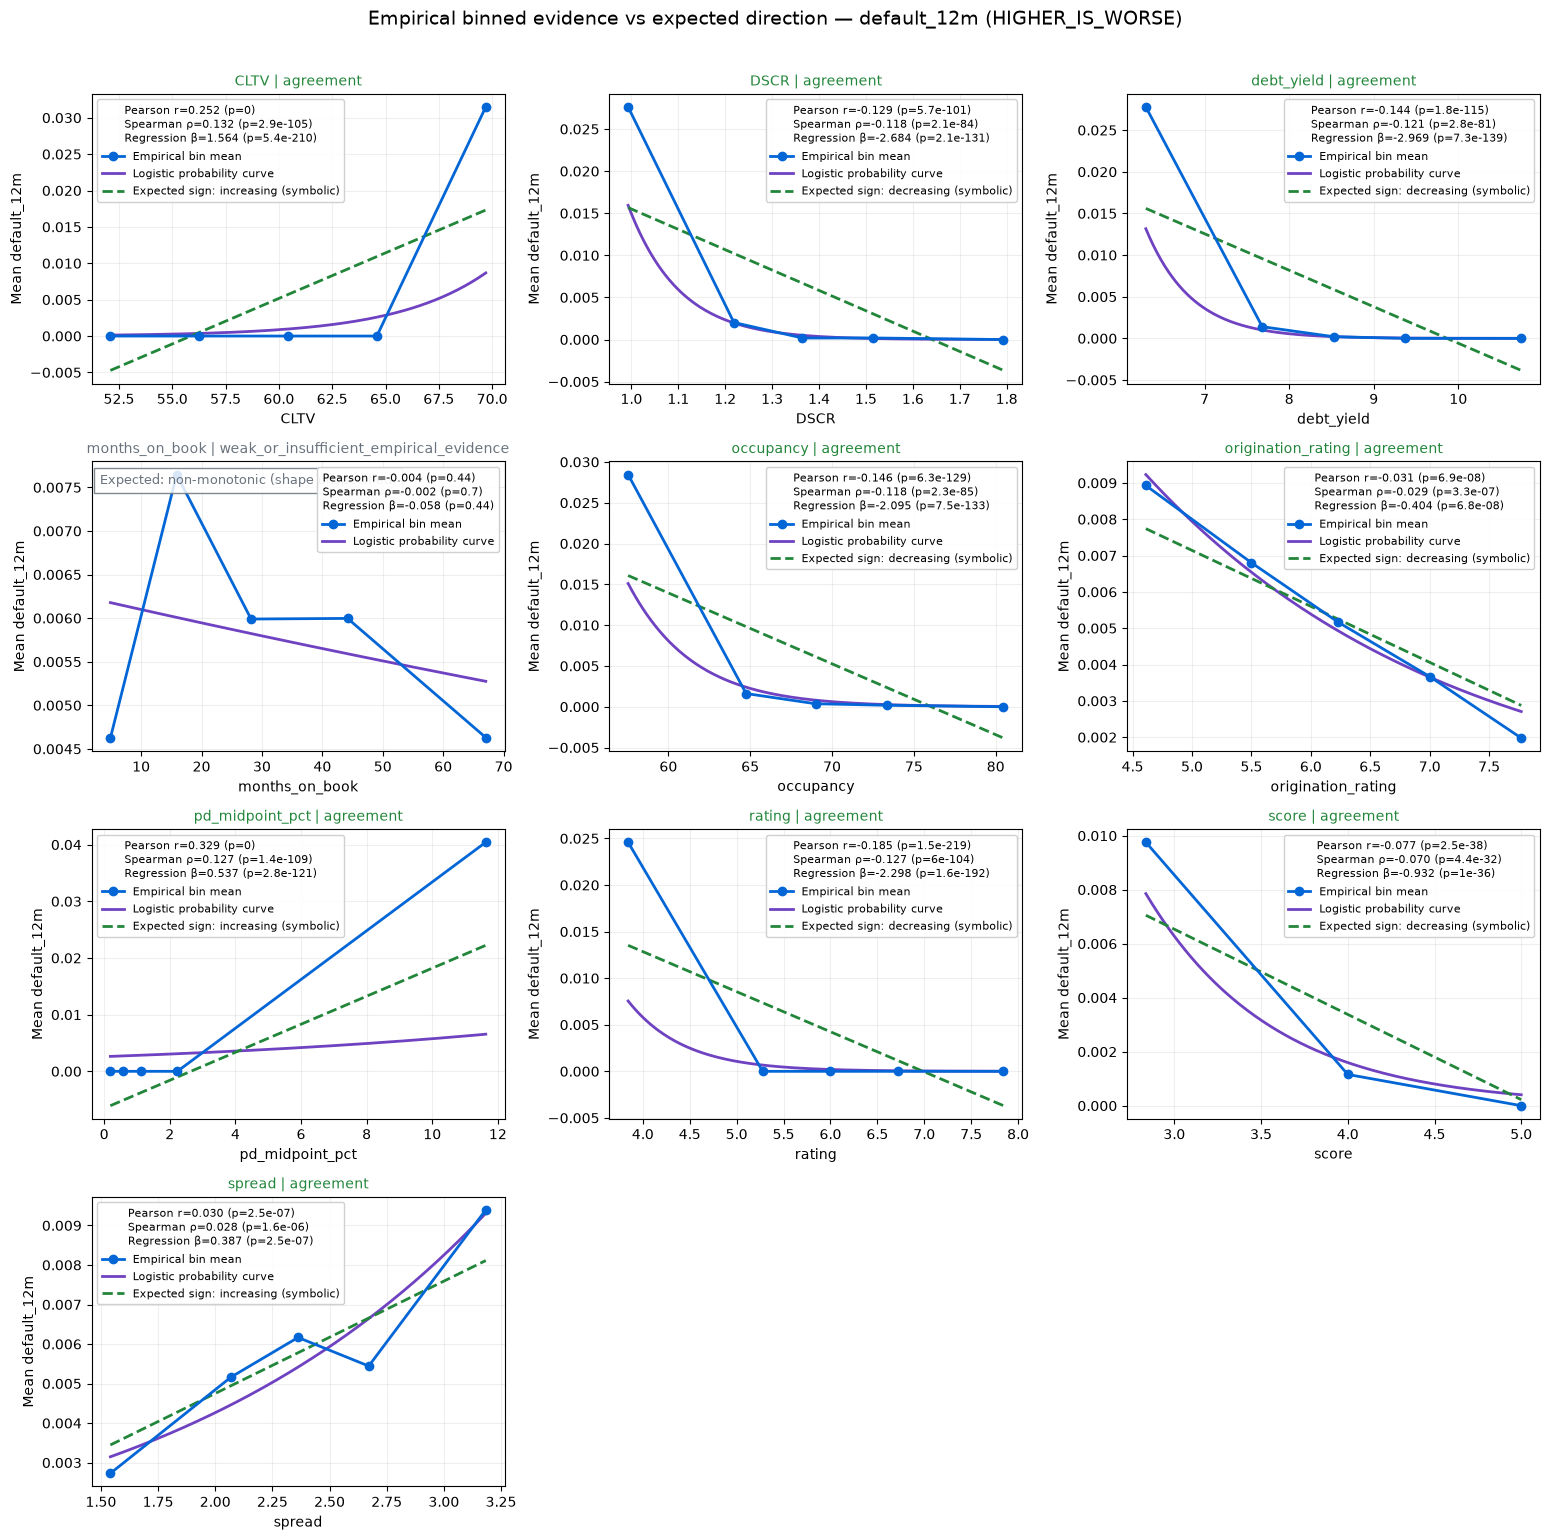

,feature_name,expected_reference_direction,observed_direction,overlay_conclusion,kb_knowledge_strength
0,CLTV,increasing,increasing,agreement,strong
1,DSCR,decreasing,decreasing,agreement,strong
2,debt_yield,decreasing,decreasing,agreement,strong
3,months_on_book,non_monotonic,weak_no_relationship,weak_or_insufficient_empirical_evidence,moderate
4,occupancy,decreasing,decreasing,agreement,strong
5,origination_rating,decreasing,decreasing,agreement,strong
6,pd_midpoint_pct,increasing,increasing,agreement,strong
7,rating,decreasing,decreasing,agreement,strong
8,score,decreasing,decreasing,agreement,strong
9,spread,increasing,increasing,agreement,moderate


In [ ]:
# Configure any completed empirical-evidence artifact here.
import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from functions.exploratory_economic_review import (
    conclusion,
    expected_reference_direction,
)
from functions.reference_configuration import ReferenceOrientation

# USER SETTINGS: change these values to point the chart at another completed evidence run.
# The orientation is essential: expected PD-risk directions are reversed for a
# HIGHER_IS_BETTER reference such as rating, and preserved for HIGHER_IS_WORSE.
# OVERLAY_SNAPSHOT_ID = "item_d982dc3d4a34"
OVERLAY_SNAPSHOT_ID = "item_e243fa4e72f4"
# OVERLAY_REFERENCE = "default_12m"
OVERLAY_REFERENCE = "default_12"
OVERLAY_REFERENCE_ORIENTATION = ReferenceOrientation.HIGHER_IS_WORSE
# OVERLAY_REFERENCE = "rating"
# OVERLAY_REFERENCE_ORIENTATION = ReferenceOrientation.HIGHER_IS_BETTER
OVERLAY_EVIDENCE_VERSION = "v0_1"
# Leave this as None to plot every feature with an economic prior. Supply a list
# to create a smaller review chart, for example ["CLTV", "DSCR", "spread"].
FEATURES_TO_PLOT = None

# Locate the experiment folder without relying on a machine-specific absolute path.
overlay_experiment_dir = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "kb" / "pd_directionality_kb_v0_3.yaml").is_file()),
    None,
)
if overlay_experiment_dir is None:
    raise RuntimeError("Run this cell from the direction-consistency experiment tree.")

# The mapping artifact contains the KB-derived feature-risk expectation. The
# evidence artifact contains observed statistics and JSON-encoded bin details.
overlay_output_dir = overlay_experiment_dir / "output"
mapping_path = overlay_output_dir / (
    f"directionality_results_{OVERLAY_SNAPSHOT_ID}_kb_v0_3.csv"
)
evidence_path = overlay_output_dir / (
    f"empirical_evidence_{OVERLAY_SNAPSHOT_ID}_{OVERLAY_REFERENCE}_"
    f"{OVERLAY_EVIDENCE_VERSION}.csv"
)

# Join one expected-direction row to one empirical-evidence row per feature.
mapping = pd.read_csv(mapping_path)
evidence = pd.read_csv(evidence_path)
overlay = mapping[[
    "feature_name", "column_expected_direction", "kb_knowledge_strength"
]].merge(evidence, on="feature_name", how="inner", validate="one_to_one")
# Convert the expectation from PD-risk space into the configured reference space.
# Example: risk-increasing becomes rating-decreasing when higher rating is better.
overlay["expected_reference_direction"] = overlay["column_expected_direction"].map(
    lambda value: expected_reference_direction(value, OVERLAY_REFERENCE_ORIENTATION)
)
# Apply the exploratory comparison taxonomy without forcing weak, unclear, or
# non-monotonic cases into a simple agreement/disagreement label.
overlay["overlay_conclusion"] = [
    conclusion(expected, observed)
    for expected, observed in zip(
        overlay["expected_reference_direction"], overlay["observed_direction"]
    )
]

# By default, omit features having no economic prior or no applicable direction.
if FEATURES_TO_PLOT is None:
    plot_rows = overlay[overlay["expected_reference_direction"].isin(
        ["increasing", "decreasing", "non_monotonic"]
    )].copy()
else:
    missing = sorted(set(FEATURES_TO_PLOT) - set(overlay["feature_name"]))
    if missing:
        raise KeyError(f"Features absent from the merged evidence: {missing}")
    plot_rows = overlay.set_index("feature_name").loc[FEATURES_TO_PLOT].reset_index()

# A chart requires the feature-bin means and reference means saved in binned_detail.
plot_rows = plot_rows[plot_rows["binned_detail"].fillna("").ne("")].copy()
if plot_rows.empty:
    raise ValueError("No selected feature has usable binned evidence.")

# Load raw values only for the plotted features. They provide the Pearson scatter
# cloud for continuous references; the saved artifact remains authoritative for stats.
overlay_workspace_root = overlay_experiment_dir.parents[2]
overlay_backend_root = overlay_workspace_root / "source-codes" / "backend"
if str(overlay_backend_root) not in sys.path:
    sys.path.insert(0, str(overlay_backend_root))
from analysis_runtime.snapshots import SnapshotLoader
from functions import extract_saved_schema

raw_columns = [OVERLAY_REFERENCE, *plot_rows["feature_name"].tolist()]
overlay_raw = SnapshotLoader().load_table(
    snapshot_id=OVERLAY_SNAPSHOT_ID, table="Data", columns=raw_columns
)
overlay_schema = extract_saved_schema.extract_saved_schema(
    extract_saved_schema._load_repository(),
    snapshot_id=OVERLAY_SNAPSHOT_ID, table="Data",
)
overlay_metadata = {
    column["name"]: column
    for table in overlay_schema["tables"] for column in table["columns"]
}

def confirmed_special_values(column_name):
    # Use only AAR-confirmed special values; never infer sentinels from magnitude.
    profile = overlay_metadata[column_name].get("profile") or {}
    return profile.get("special_values") or [] if profile.get("special_values_confirmed") else []

def clean_overlay_pairs(feature_name):
    pairs = pd.DataFrame({
        "feature": pd.to_numeric(overlay_raw[feature_name], errors="coerce"),
        "reference": pd.to_numeric(overlay_raw[OVERLAY_REFERENCE], errors="coerce"),
    }).replace([np.inf, -np.inf], np.nan)
    feature_specials = {float(value) for value in confirmed_special_values(feature_name)}
    reference_specials = {float(value) for value in confirmed_special_values(OVERLAY_REFERENCE)}
    special_mask = pairs["feature"].isin(feature_specials) | pairs["reference"].isin(reference_specials)
    return pairs.mask(special_mask).dropna()

# Build a compact three-column chart grid; unused panels are hidden below.
ncols = 3
nrows = math.ceil(len(plot_rows) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.8 * nrows), squeeze=False)
# Title/expectation colors make agreement, disagreement, and review cases scannable.
conclusion_colors = {
    "agreement": "#22863a",
    "disagreement": "#cb2431",
    "expected_non_monotonic_confirmed": "#22863a",
    "expected_non_monotonic_not_confirmed": "#b08800",
}

# Draw one panel per feature. For continuous references, faint points form the raw
# Pearson cloud. The solid blue series is the observed quantile-bin relationship.
for axis, (_, row) in zip(axes.flat, plot_rows.iterrows()):
    bins = pd.DataFrame(json.loads(row["binned_detail"]))
    x = bins["feature_mean"].to_numpy(dtype=float)
    y = bins["reference_mean"].to_numpy(dtype=float)
    color = conclusion_colors.get(row["overlay_conclusion"], "#6a737d")
    if row["reference_kind"] == "CONTINUOUS":
        pairs = clean_overlay_pairs(row["feature_name"])
        cloud = pairs.sample(n=min(2500, len(pairs)), random_state=11)
        axis.scatter(
            cloud["feature"], cloud["reference"], s=8, alpha=0.10,
            color="#6a737d", edgecolors="none", label="Raw paired sample", zorder=1,
        )
    axis.plot(
        x, y, color="#0366d6", marker="o", linewidth=2,
        label="Empirical bin mean", zorder=3,
    )

    # Reconstruct the fitted model from audited standardized parameters. Continuous
    # references get a linear fit; binary references get a logistic probability curve.
    model_x = np.linspace(float(x.min()), float(x.max()), 200)
    model_z = (model_x - row["regression_feature_mean"]) / row["regression_feature_std"]
    model_eta = row["regression_intercept"] + row["regression_coefficient"] * model_z
    if row["regression_model"] == "univariate_logistic_standardized":
        model_y = 1.0 / (1.0 + np.exp(-np.clip(model_eta, -35, 35)))
        model_label = "Logistic probability curve"
    else:
        model_y = row["regression_reference_mean"] + row["regression_reference_std"] * model_eta
        model_label = "Linear regression fit"
    axis.plot(model_x, model_y, color="#6f42c1", linewidth=2, label=model_label, zorder=2)

    # Overlay only the expected sign. Its dashed-line slope is symbolic and must
    # not be interpreted as a predicted effect size or fitted model.
    expected = row["expected_reference_direction"]
    if expected in {"increasing", "decreasing"}:
        y_span = float(np.ptp(y))
        if y_span == 0:
            y_span = max(abs(float(np.mean(y))) * 0.05, 1e-6)
        midpoint = float(np.mean(y))
        delta = 0.35 * y_span
        expected_y = (
            [midpoint - delta, midpoint + delta]
            if expected == "increasing"
            else [midpoint + delta, midpoint - delta]
        )
        axis.plot(
            [x.min(), x.max()], expected_y, color=color, linestyle="--", linewidth=2,
            label=f"Expected sign: {expected} (symbolic)",
        )
    else:
        # The KB does not specify whether a non-monotonic shape is U-shaped or
        # inverted-U, so label it rather than inventing a curve.
        axis.text(
            0.02, 0.96, "Expected: non-monotonic (shape unspecified)",
            transform=axis.transAxes, va="top", color=color, fontsize=9,
            bbox={"facecolor": "white", "edgecolor": color, "alpha": 0.85},
        )

    axis.set_title(
        f"{row['feature_name']} | {row['overlay_conclusion']}", color=color, fontsize=10
    )
    # Pearson and Spearman are scalar summaries, so show their estimates and
    # p-values in a statistics box rather than inventing separate correlation lines.
    statistics_text = (
        f"Pearson r={row['pearson_coefficient']:.3f} (p={row['pearson_p_value']:.2g})\n"
        f"Spearman ρ={row['spearman_coefficient']:.3f} (p={row['spearman_p_value']:.2g})\n"
        f"Regression β={row['regression_coefficient']:.3f} (p={row['regression_p_value']:.2g})"
    )
    axis.set_xlabel(row["feature_name"])
    axis.set_ylabel(f"Mean {OVERLAY_REFERENCE}")
    axis.grid(alpha=0.2)
    # Put the scalar statistics in the same movable box as the series legend.
    # loc='best' lets Matplotlib choose the least obstructive corner per panel.
    panel_legend = axis.legend(
        fontsize=8, loc="best", title=statistics_text, title_fontsize=8, framealpha=0.92
    )
    panel_legend.get_title().set_multialignment("left")

# Hide empty grid positions when the feature count is not a multiple of three.
for axis in axes.flat[len(plot_rows):]:
    axis.set_visible(False)

fig.suptitle(
    f"Empirical binned evidence vs expected direction — {OVERLAY_REFERENCE} "
    f"({OVERLAY_REFERENCE_ORIENTATION.value})",
    fontsize=14, y=1.01,
)
fig.tight_layout()
plt.show()

# Finish with the exact comparison labels behind the chart for auditable review.
display(plot_rows[[
    "feature_name", "expected_reference_direction", "observed_direction",
    "overlay_conclusion", "kb_knowledge_strength"
]].reset_index(drop=True))
